In [1]:
import os
from ax.service.ax_client import AxClient
import ax
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# exp, drug, surfactant dictionaries

exp_dict = {
    'IBP': {'experiment_folder': '2026-02-19','iteration': 10,},
    'LOV': {'experiment_folder': '2026-02-20','iteration': 10,},
    'DCF': {'experiment_folder': '2026-02-23','iteration': 10,},
    'GLV': {'experiment_folder': '2026-02-26','iteration': 10,}
}


drug_dict = {
    "IBP": {"full_name": "Ibuprofen", "abbr": "IBP", "CAS": "15687-27-1", "smiles": "O=C(O)C(C1=CC=C(C=C1)CC(C)C)C"},
    "DCF": {"full_name": "Diclofenac", "abbr": "DCF", "CAS": "15307-86-5", "smiles": "O=C(O)CC=1C=CC=CC1NC=2C(Cl)=CC=CC2Cl"},
    "LOV": {"full_name": "Lovastatin", "abbr": "LOV", "CAS": "75330-75-5", "smiles": "O=C1OC(CCC2C(C=CC3=CC(C)CC(OC(=O)C(C)CC)C32)C)CC(O)C1"}, 
    "GLV": {"full_name": "Griseofulvin", "abbr": "GLV", "CAS": "126-07-8", "smiles": "O=C1C=C(OC)C2(OC=3C(Cl)=C(OC)C=C(OC)C3C2=O)C(C)C1"}, 
}


surfactant_dict = {
    's1':{"abbr": "SDS", "full_name": "Sodium Dodecyl Sulfate"},
    's2':{"abbr": "NaC", "full_name": "Sodium Cholate"},
    's3':{"abbr": "CHAPS", "full_name": "3-[(3-Cholamidopropyl)dimethylammonio]-1-propanesulfonate"},
    's4':{"abbr": "DTAB", "full_name": "Dodecyltrimethylammonium Bromide"},
    's5':{"abbr": "TTAB", "full_name": "Tetradecyltrimethylammonium Bromide"},
    's6':{"abbr": "P188", "full_name": "Poloxamer 188"},
    's7':{"abbr": "P407", "full_name": "Poloxamer 407"},
    's8':{"abbr": "SB3-12", "full_name": "Lauryl Sulfobetaine"},
}

In [3]:
# data processing functions

def add_iteration_number(df, trials_per_iteration, num_random_trials):
    df = df.copy()
    df['iteration'] = 0
    mask = df['trial_index'] >= num_random_trials
    df.loc[mask, 'iteration'] = ((df.loc[mask, 'trial_index'] - num_random_trials) // trials_per_iteration) + 1
    return df

def add_success_column(df, threshold):
    df = df.copy()
    df['success'] = (df['absorbance'] < threshold).astype(int)
    return df

# replace the column names s1 to s8 to surfactant names
def replace_surfacant_names(df):
    df = df.copy()
    df = df.rename(columns={key: surfactant_dict[key]['abbr'] for key in surfactant_dict.keys()})
    return df


In [4]:
# data processing

for drug in exp_dict.keys():

    experiment_folder = exp_dict[drug]['experiment_folder']
    iteration = exp_dict[drug]['iteration']

    optimizer_path = f'../{experiment_folder}/optimizer/optimizer_{iteration}_loaded.json'
    params_path = f'../{experiment_folder}/experiment_parameters.csv'


    exp_params = pd.read_csv(params_path)
    exp_params_dict = dict(zip(exp_params.iloc[:, 0], exp_params.iloc[:, 1]))

    exp_dict[drug]['exp_params'] = exp_params_dict

    ax_client = AxClient.load_from_json_file(optimizer_path)
    df = ax_client.get_trials_data_frame()

    df = add_iteration_number(df, int(exp_params_dict['TRIALS_PER_ITERATION']), int(exp_params_dict['NUM_RANDOM_TRIALS']))
    df = add_success_column(df, float(exp_params_dict['ABSORBANCE_THRESHOLD']))
    df = replace_surfacant_names(df)


    exp_dict[drug]['results'] = df

    exp_dict[drug]['ax_client'] = ax_client


/Users/zeqing/opt/anaconda3/envs/drug-surfactant/lib/python3.10/site-packages/ax/storage/json_store/decoder.py:303: AxParameterWarning: `sort_values` is not specified for `ChoiceParameter` "drug". Defaulting to `False` for parameters of `ParameterType` STRING. To override this behavior (or avoid this warning), specify `sort_values` during `ChoiceParameter` construction.
  return _class(
[INFO 03-02 16:46:50] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[WARNING 03-02 16:46:50] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.
/Users/zeqing/opt/anaconda3/envs/drug-surfactant/lib/python3.10/site-packages/ax/storage/json_store/decoder.py:303: AxParameterWarning: `sort_values` is not specified for `ChoiceParameter` "drug". Defaulting to `False` for parameters of `ParameterType` STRING. To overrid

In [18]:
def plot_surfactant_combined(df, drug, success_only=False, transparent=False):
    from matplotlib.patches import Polygon
    import matplotlib.gridspec as gridspec

    surfactants = [surfactant_dict[key]['abbr'] for key in surfactant_dict.keys()][::-1]


    palette = [
        '#4878CF', '#6ACC65', "#F36D6D", '#B47CC7',
        '#C4AD66', '#77BEDB', '#E68310', "#911828"
    ]


    # Always use full df for best-so-far; success_only only affects stacked bars & bubble
    all_iters   = sorted(df['iteration'].unique())
    data        = df[df['success'] == 1] if success_only else df
    iters       = list(all_iters)
    n_iter      = len(iters)
    grouped     = data.groupby('iteration')[surfactants].mean().reindex(all_iters)

    region_defs = [
        (0, 0,           '#888888', 'Random'),
        (1, 4,           '#3A7DC9', 'Explore'),
        (5, 8,           '#2A9D5C', 'Explore/Exploit'),
        (9, max(iters),  '#C05046', 'Exploit'),
    ]

    # ── Best-so-far computation (always from full df, success==1) ──────
    successful       = df[df['success'] == 1]
    iter_best        = successful.groupby('iteration')['obj_total_vol'].min()
    iter_best_full   = iter_best.reindex(all_iters)
    best_so_far      = iter_best_full.cummin().ffill()

    rc = {
        'font.family': 'DejaVu Sans', 'font.size': 11,
        'axes.linewidth': 0.8,
        'axes.spines.top': False, 'axes.spines.right': False,
        'xtick.direction': 'out', 'ytick.direction': 'out',
        'xtick.major.size': 4, 'ytick.major.size': 4,
        'legend.frameon': True, 'legend.framealpha': 0.9,
        'legend.edgecolor': '#cccccc',
    }

    bar_w = 0.55

    def get_region_x_bounds(lo, hi):
        xs = [x for x in iters if lo <= x <= hi]
        if not xs:
            return None
        return min(xs) - bar_w / 2 - 0.1, max(xs) + bar_w / 2 + 0.1

    def draw_region_shading(ax):
        for lo, hi, color, label in region_defs:
            bounds = get_region_x_bounds(lo, hi)
            if bounds is None:
                continue
            x0, x1 = bounds
            ax.axvspan(x0, x1, color=color, alpha=0.06, zorder=0, linewidth=0)

    def sep_lines(ax):
        for sx in [0.5, 4.5, 8.5]:
            if min(iters) < sx < max(iters):
                ax.axvline(sx, color='#444444', lw=1.0,
                           linestyle='--', dashes=(5, 3), zorder=4, alpha=0.5)

    def region_labels(ax, y_bracket, y_text):
        for lo, hi, color, label in region_defs:
            xs = [x for x in iters if lo <= x <= hi]
            if not xs:
                continue
            ax.annotate('', xy=(max(xs) + 0.45, y_bracket),
                        xytext=(min(xs) - 0.45, y_bracket),
                        arrowprops=dict(arrowstyle='-', color=color, lw=1.4))
            ax.text((min(xs) + max(xs)) / 2, y_text, label,
                    ha='center', va='bottom', fontsize=9,
                    color=color, fontweight='semibold')

    with plt.rc_context(rc):
        fig = plt.figure(figsize=(20, 13),
                         facecolor='none' if transparent else 'white')
        gs = gridspec.GridSpec(3, 2,
                               height_ratios=[1, 1, 1],
                               width_ratios=[1, 0.13],
                               hspace=0.25, wspace=0.04)
        ax_best = fig.add_subplot(gs[1, 0])
        ax_top  = fig.add_subplot(gs[0, 0], sharex=ax_best)
        ax_bot  = fig.add_subplot(gs[2, 0], sharex=ax_best)
        ax_leg  = fig.add_subplot(gs[:, 1])
        ax_leg.axis('off')

        if transparent:
            for ax in [ax_best, ax_top, ax_bot]:
                ax.set_facecolor('none')

        x_lo = min(iters) - bar_w
        x_hi = max(iters) + bar_w

        # ══ BEST-SO-FAR ════════════════════════════════════════════════
        draw_region_shading(ax_best)

        valid_bsf = best_so_far.dropna()
        ax_best.step(valid_bsf.index, valid_bsf.values,
                     where='post', color='#C05046', lw=2.0,
                     zorder=5, label='Best so far')
        ax_best.fill_between(valid_bsf.index, valid_bsf.values,
                             valid_bsf.values.max() * 1.00,
                             step='post', color='#C05046', alpha=0.08, zorder=0)

        bsf_min = valid_bsf.min() if len(valid_bsf) else 0
        bsf_max = valid_bsf.max() if len(valid_bsf) else 1
        pad = (bsf_max - bsf_min) * 0.25 if bsf_max > bsf_min else 1
        ax_best.set_ylim(max(0, bsf_min - pad), bsf_max + pad * 1.5)
        ax_best.set_xlim(x_lo, x_hi)
        ax_best.set_ylabel('Best/Lowest Surfactant Vol (µL)', fontsize=11, labelpad=6)
        ax_best.yaxis.grid(True, color='#e0e0e0', linewidth=0.6, zorder=1)
        ax_best.set_axisbelow(True)
        sep_lines(ax_best)
        plt.setp(ax_best.get_xticklabels(), visible=False)

        # ══ STACKED BARS ═══════════════════════════════════════════════
        cum = np.zeros(n_iter)
        bar_bottoms, bar_tops = [], []
        for s in surfactants:
            bar_bottoms.append(cum.copy())
            cum = cum + grouped[s].values
            bar_tops.append(cum.copy())

        y_max = bar_tops[-1].max()
        draw_region_shading(ax_top)

        for j, s in enumerate(surfactants):
            color = palette[j]
            for i in range(n_iter - 1):
                xl = iters[i]   + bar_w / 2
                xr = iters[i+1] - bar_w / 2
                poly = Polygon(list(zip(
                    [xl, xr, xr, xl],
                    [bar_tops[j][i],      bar_tops[j][i+1],
                     bar_bottoms[j][i+1], bar_bottoms[j][i]]
                )), closed=True, facecolor=color, alpha=0.18, linewidth=0)
                ax_top.add_patch(poly)
                ax_top.plot([xl, xr], [bar_tops[j][i],     bar_tops[j][i+1]],
                            color=color, lw=0.7, alpha=0.55, zorder=2)
                ax_top.plot([xl, xr], [bar_bottoms[j][i],  bar_bottoms[j][i+1]],
                            color=color, lw=0.7, alpha=0.55, zorder=2)

        for j, s in enumerate(surfactants):
            ax_top.bar(iters, grouped[s].values, width=bar_w,
                       bottom=bar_bottoms[j], color=palette[j],
                       alpha=0.88, linewidth=0.4, edgecolor='white',
                       label=s, zorder=3)

        ax_top.set_ylim(0, y_max * 1.28)
        ax_top.set_xlim(x_lo, x_hi)
        ax_top.set_ylabel('Mean Surfactant Vol (µL)', fontsize=11, labelpad=6)
        ax_top.yaxis.grid(True, color='#e0e0e0', linewidth=0.6, zorder=1)
        ax_top.set_axisbelow(True)
        sep_lines(ax_top)
        region_labels(ax_top, y_max * 1.12, y_max * 1.17)
        plt.setp(ax_top.get_xticklabels(), visible=False)

        handles, labels_leg = ax_top.get_legend_handles_labels()
        ax_top.legend(handles[::-1], labels_leg[::-1],
                      title='Surfactant', title_fontsize=14,
                      fontsize=12, loc='upper left',
                      bbox_to_anchor=(1.02, 1),
                      borderaxespad=0, handlelength=1.2,
                      frameon=True, framealpha=0., edgecolor='#cccccc')

        # ══ BUBBLE GRID ════════════════════════════════════════════════
        n_surf   = len(surfactants)
        max_val  = grouped.values.max()
        max_area = 1600

        def to_area(v):
            return (v / max_val) * max_area if max_val > 0 else max_area * 0.5

        draw_region_shading(ax_bot)

        for i in range(n_surf):
            if i % 2 == 0:
                ax_bot.axhspan(i - 0.5, i + 0.5,
                               color='#000000', alpha=0.03, zorder=0)
        for it in iters:
            ax_bot.axvline(it, color='#e0e0e0', lw=0.6, zorder=1)

        for j, s in enumerate(surfactants):
            for it in iters:
                val = grouped.loc[it, s]
                if pd.notna(val):
                    ax_bot.scatter(it, j, s=to_area(val),
                                   c=palette[j], alpha=0.82,
                                   edgecolors='white', linewidths=0.6, zorder=3)

        sep_lines(ax_bot)
        ax_bot.set_ylim(-0.7, n_surf - 0.5)
        ax_bot.set_xlim(x_lo, x_hi)
        ax_bot.set_yticks(range(n_surf))
        ax_bot.set_yticklabels(surfactants, fontsize=10)
        ax_bot.set_xticks(iters)
        ax_bot.set_xticklabels([str(int(it)) for it in iters], fontsize=10)
        ax_bot.set_xlabel('Iteration', fontsize=11, labelpad=6)
        ax_bot.set_ylabel('Surfactant', fontsize=11, labelpad=6)

        title = f"{drug_dict[drug]['full_name']} ({drug_dict[drug]['abbr']})"
        fig.suptitle(title, fontsize=18, y=0.93)

        # ── Panel labels ───────────────────────────────────────────────
        for ax, label in [(ax_top, 'a)'), (ax_best, 'b)'), (ax_bot, 'c)')]:
            ax.text(-0.020, 1.04, label, transform=ax.transAxes,
                    fontsize=12, va='bottom', ha='left')

        fig.tight_layout()
        plt.show()

        # save to figures
        save_path = f'figures/{drug_dict[drug]["abbr"]}_optimization_trace.png'
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())



Plotting IBP...
--------------------------------------------------------------------------------


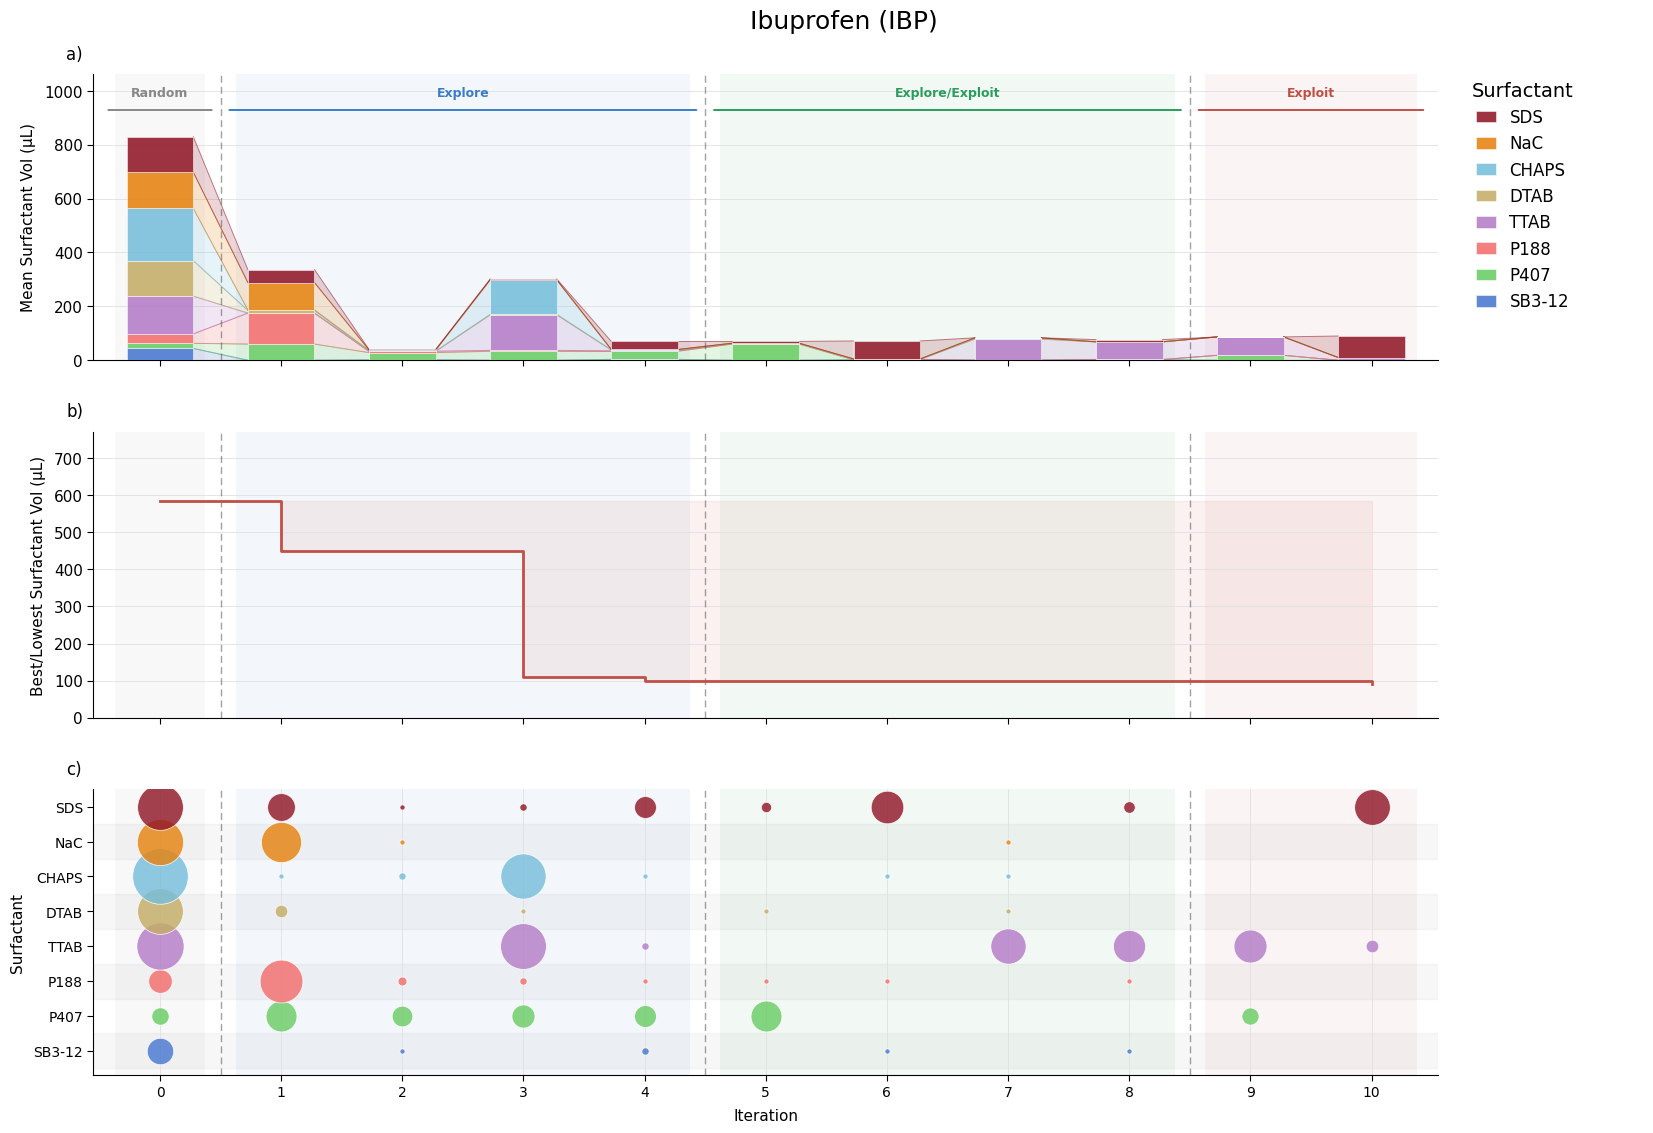

--------------------------------------------------------------------------------
Plotting LOV...
--------------------------------------------------------------------------------


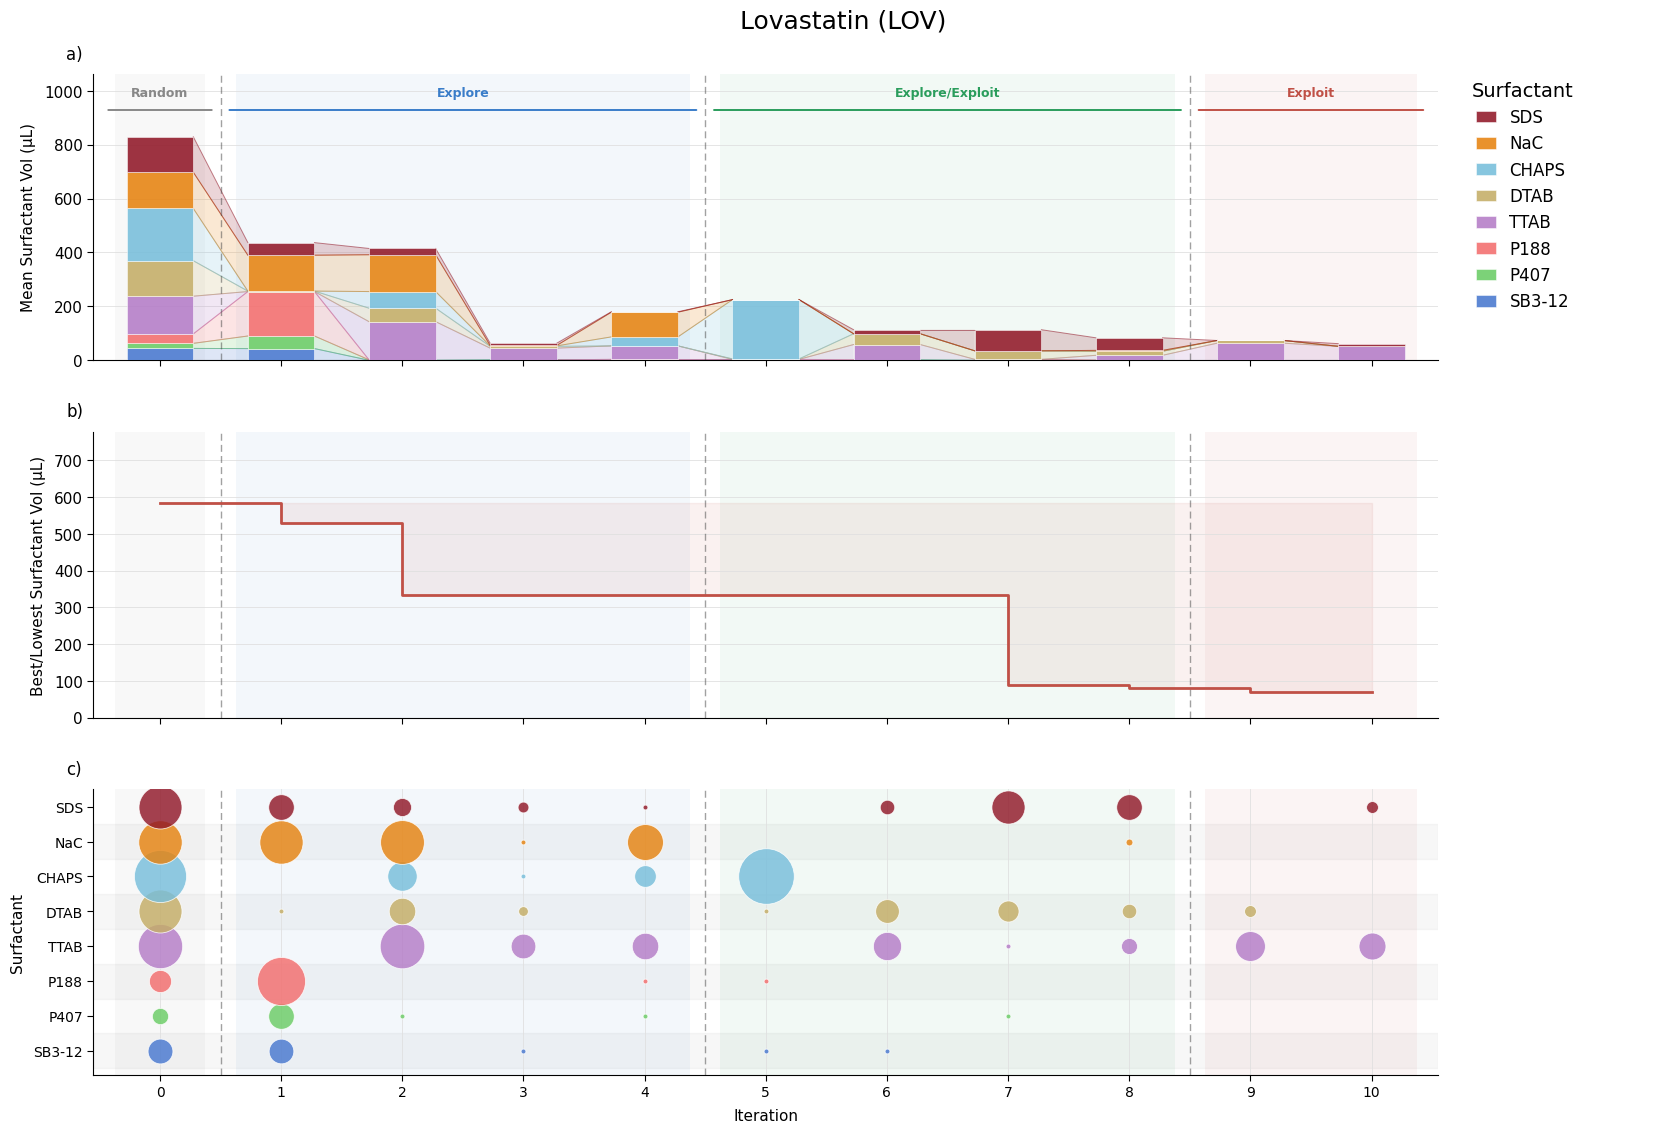

--------------------------------------------------------------------------------
Plotting DCF...
--------------------------------------------------------------------------------


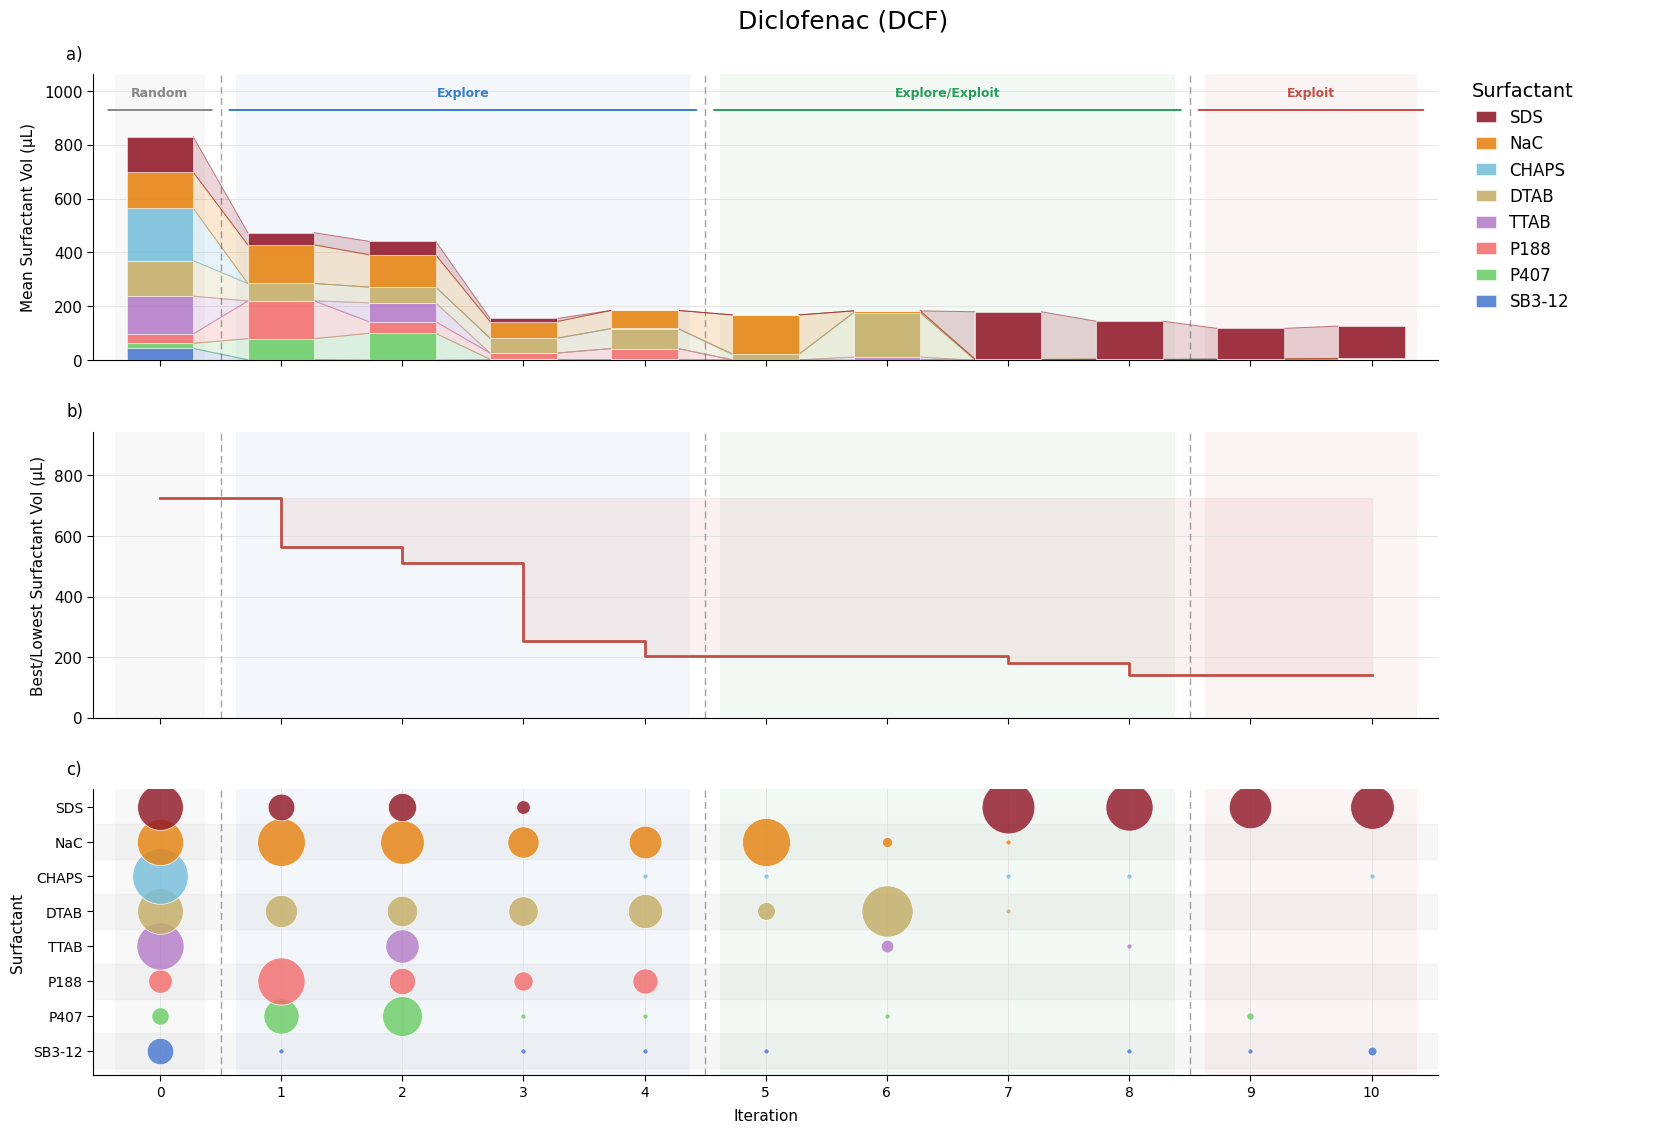

--------------------------------------------------------------------------------
Plotting GLV...
--------------------------------------------------------------------------------


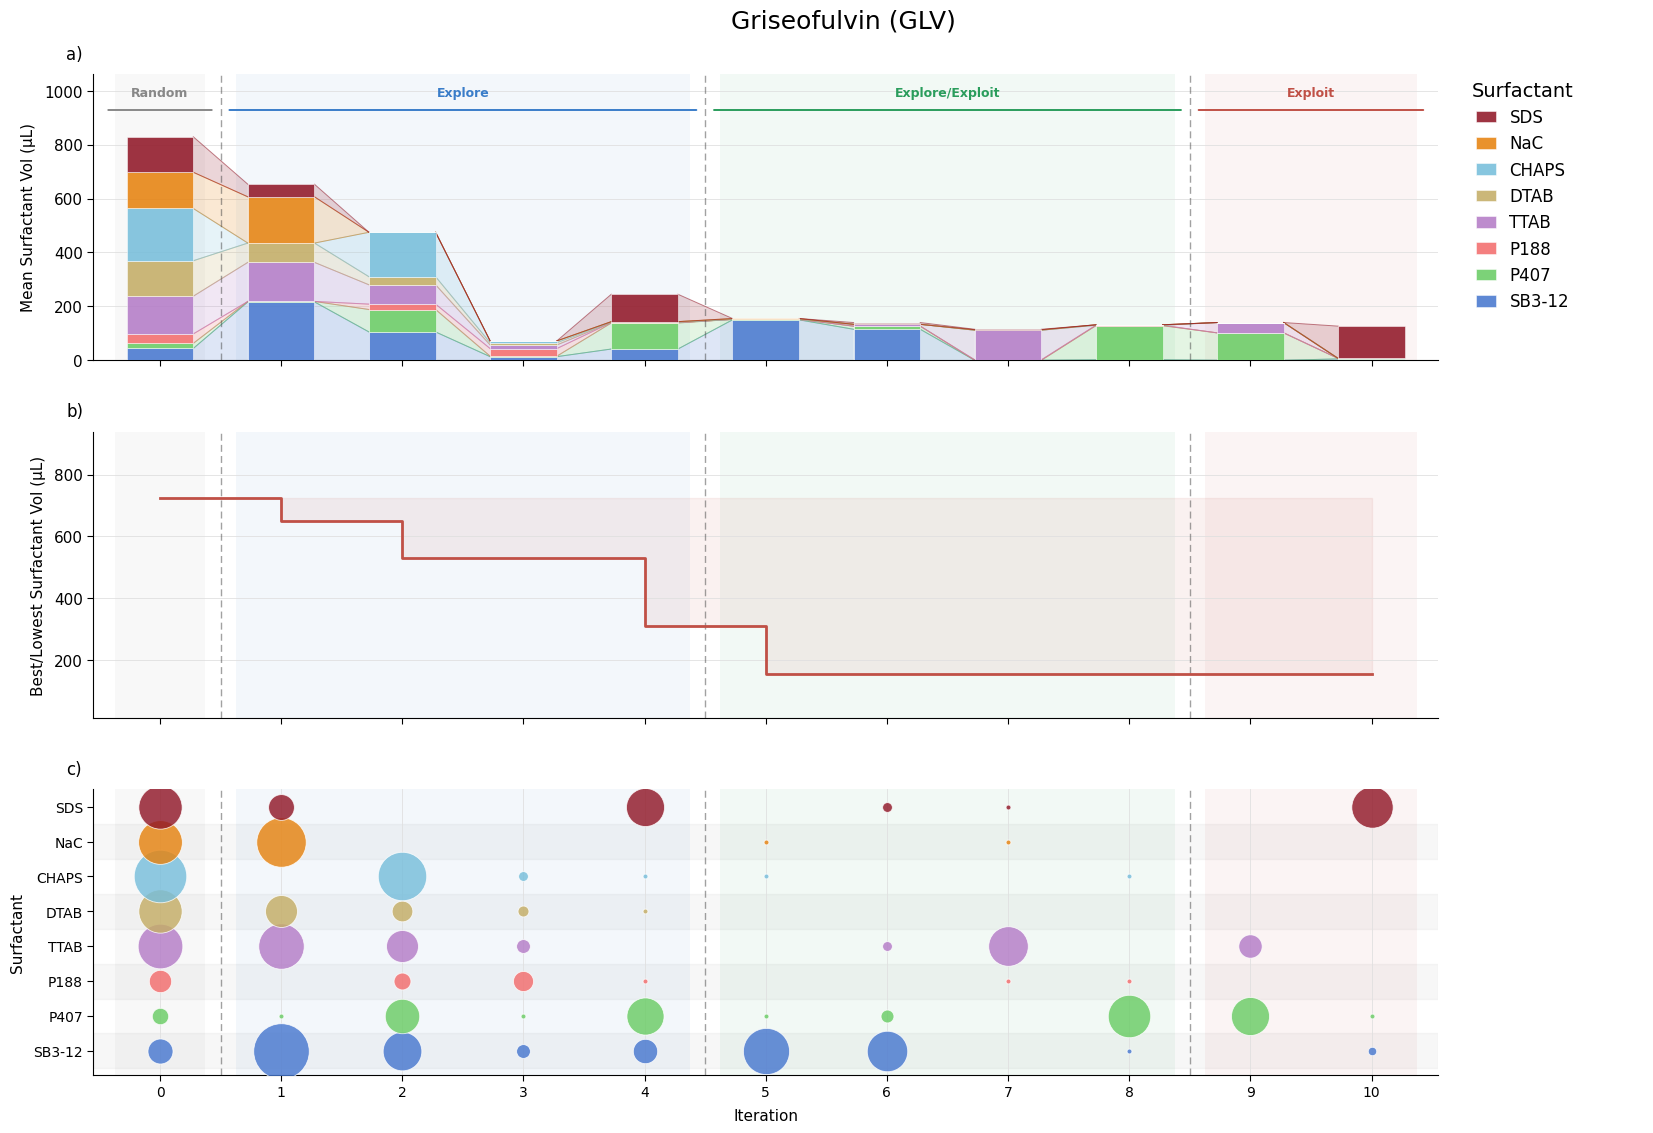

--------------------------------------------------------------------------------


In [19]:
for drug in exp_dict.keys():

    print(f"Plotting {drug}...")
    print('-' * 80)
    df = exp_dict[drug]['results']
    plot_surfactant_combined(df, drug)
    print('-' * 80)


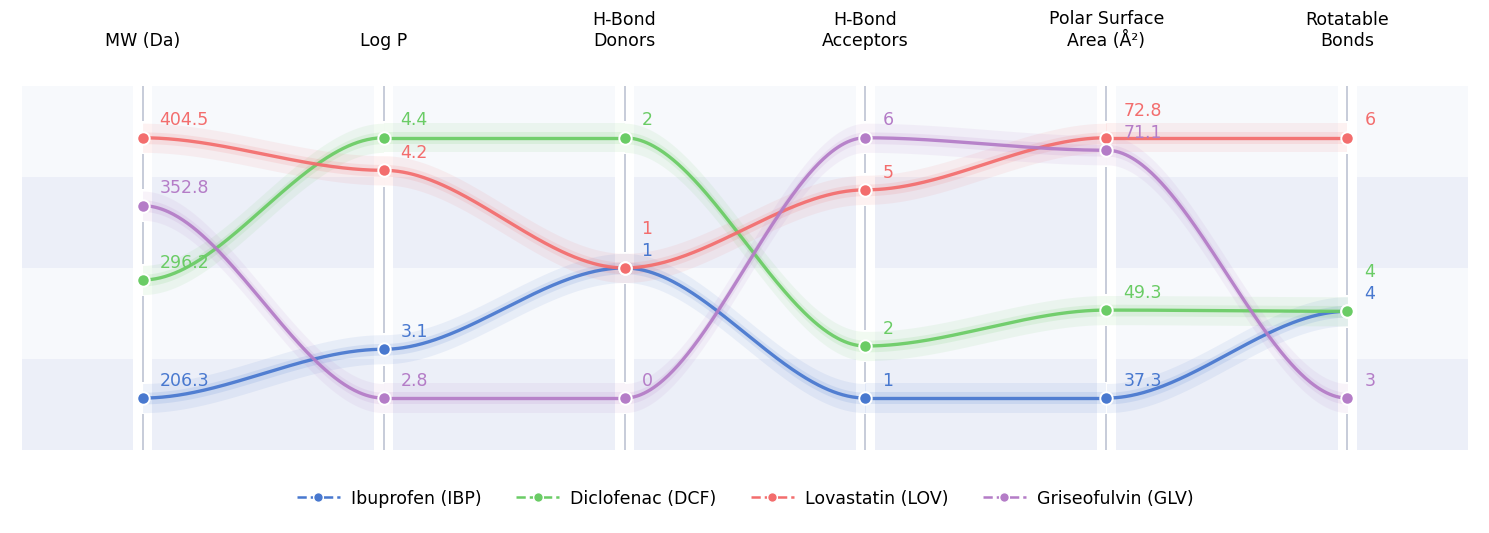

In [15]:
def drug_visualization(drug_dict):
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors
    from matplotlib.patches import Rectangle
    import numpy as np
    import matplotlib.pyplot as plt

    prop_keys   = ['mol_weight', 'log_p', 'hbd', 'hba', 'tpsa', 'rot_bonds']
    axes_labels = [
        'MW (Da)',
        'Log P',
        'H-Bond\nDonors',
        'H-Bond\nAcceptors',
        'Polar Surface\nArea (Å²)',
        'Rotatable\nBonds',
    ]

    # ── Compute properties from SMILES ────────────────────────────────
    abbrs = list(drug_dict.keys())
    data  = {}
    for abbr, info in drug_dict.items():
        mol = Chem.MolFromSmiles(info['smiles'])
        data[abbr] = {
            'full_name':  info['full_name'],
            'mol_weight': round(Descriptors.MolWt(mol), 1),
            'log_p':      round(Descriptors.MolLogP(mol), 1),
            'hbd':        rdMolDescriptors.CalcNumHBD(mol),
            'hba':        rdMolDescriptors.CalcNumHBA(mol),
            'tpsa':       round(rdMolDescriptors.CalcTPSA(mol), 1),
            'rot_bonds':  rdMolDescriptors.CalcNumRotatableBonds(mol),
        }

    # Office 2019 accent palette: blue / green / red / purple
    colors = ['#4472C4', '#70AD47', '#C00000', '#7030A0']
    colors = ['#4878CF', '#6ACC65', '#F36D6D', '#B47CC7']
    n_axes = len(prop_keys)
    xs     = np.arange(n_axes, dtype=float)

    # ── Per-axis normalisation: 20% padding beyond actual min/max ─────
    def norm(key, val):
        lo  = min(data[a][key] for a in abbrs)
        hi  = max(data[a][key] for a in abbrs)
        rng = hi - lo if hi != lo else 1.0
        return (val - (lo - 0.20 * rng)) / (1.40 * rng)

    # ── Per-segment sigmoid (cubic Hermite, zero endpoint tangents) ───
    # y(t) = y0*(1-t)^2*(1+2t) + y1*t^2*(3-2t)   t in [0,1]
    def sigmoid_segment(x0, y0, x1, y1, n=150):
        t  = np.linspace(0, 1, n)
        xf = x0 + t * (x1 - x0)
        yf = y0 * (1 - t)**2 * (1 + 2*t) + y1 * t**2 * (3 - 2*t)
        return xf, yf

    # ── Figure ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 5.5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.set_xlim(-0.55, n_axes - 0.45)
    ax.set_ylim(-0.20, 1.2)
    ax.axis('off')

    # ── Background bands: segmented per column, with gaps at each axis ─
    # Gap on each side of every axis line so bands appear "divided"
    BGGAP = 0.04
    band_colors = ['#ECEFF8', '#F7F9FC']
    # Column x-boundaries: left edge, between axes, right edge
    col_edges = (
        [xs[0] - 0.5] +
        [x + BGGAP for x in xs[:-1]] +
        [xs[-1] + 0.5]
    )
    # Each inter-axis column spans col_edges[i] .. col_edges[i+1],
    # but split at internal axis gaps: left half and right half
    # Simpler: just draw one rect per gap-delimited segment
    seg_bounds = []
    seg_bounds.append((xs[0] - 0.5, xs[0] - BGGAP))   # leftmost stub
    for i in range(n_axes - 1):
        seg_bounds.append((xs[i] + BGGAP, xs[i+1] - BGGAP))
    seg_bounds.append((xs[-1] + BGGAP, xs[-1] + 0.5))  # rightmost stub

    for i in range(4):
        y0_band = i * 0.25
        for x_left, x_right in seg_bounds:
            rect = Rectangle(
                (x_left, y0_band), x_right - x_left, 0.25,
                facecolor=band_colors[i % 2], alpha=1.0,
                linewidth=0, zorder=0, transform=ax.transData
            )
            ax.add_patch(rect)

    # ── Pre-compute normalised y ──────────────────────────────────────
    all_yn = {a: np.array([norm(k, data[a][k]) for k in prop_keys]) for a in abbrs}

    # ── Vertical axis lines with white gaps where curves cross ────────
    AXGAP = 0.045
    for axis_i, xi in enumerate(xs):
        crossings = sorted(all_yn[a][axis_i] for a in abbrs)
        breaks = []
        for yc in crossings:
            lo_b, hi_b = yc - AXGAP, yc + AXGAP
            if breaks and lo_b < breaks[-1][1]:
                breaks[-1] = (breaks[-1][0], max(hi_b, breaks[-1][1]))
            else:
                breaks.append((lo_b, hi_b))
        segments = []
        prev = 0.0
        for lo_b, hi_b in breaks:
            if prev < lo_b:
                segments.append((prev, lo_b))
            prev = hi_b
        if prev < 1.0:
            segments.append((prev, 1.0))
        for y0_seg, y1_seg in segments:
            ax.plot([xi, xi], [y0_seg, y1_seg], color='#B8BED0', lw=1.1,
                    zorder=2, solid_capstyle='butt')

    # ── Draw continuous per-segment sigmoid curves ────────────────────
    for abbr, color in zip(abbrs, colors):
        yn = all_yn[abbr]

        for seg in range(n_axes - 1):
            xf, yf = sigmoid_segment(xs[seg], yn[seg], xs[seg+1], yn[seg+1])
            # Two-layer glow
            ax.fill_between(xf, yf - 0.040, yf + 0.040,
                            color=color, alpha=0.09, linewidth=0, zorder=3)
            ax.fill_between(xf, yf - 0.016, yf + 0.016,
                            color=color, alpha=0.13, linewidth=0, zorder=3)
            # Main solid curve (continuous)
            ax.plot(xf, yf, color=color, lw=2.4, alpha=0.93, zorder=4,
                    solid_capstyle='round', solid_joinstyle='round')

        # White-bordered circle markers at each axis
        for xi, y in zip(xs, yn):
            ax.scatter(xi, y, s=80, color=color, zorder=6,
                       edgecolors='white', linewidths=1.4)

    # ── Value labels: bottom-up to prevent upward stacking drift ─────
    for axis_i, key in enumerate(prop_keys):
        xi = float(axis_i)
        entries = sorted(
            [(all_yn[a][axis_i], data[a][key], colors[j])
             for j, a in enumerate(abbrs)],
            key=lambda t: t[0]
        )
        placed_y = []
        for y_norm, raw_val, color in entries:
            y_text = y_norm + 0.025
            if placed_y and y_text < placed_y[-1] + 0.060:
                y_text = placed_y[-1] + 0.060
            placed_y.append(y_text)
            ax.text(xi + 0.07, y_text, str(raw_val),
                    fontsize=12.5, color=color, ha='left', va='bottom',
                     zorder=7)

    # ── Column headers ────────────────────────────────────────────────
    for xi, label in zip(xs, axes_labels):
        ax.text(xi, 1.10, label, ha='center', va='bottom',
                fontsize=12.5, color="#000000",
                multialignment='center', zorder=8)

    # ── Legend ────────────────────────────────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], color=colors[i], lw=1.8, linestyle='--',
                   marker='o', markersize=7,
                   markerfacecolor=colors[i], markeredgecolor='white',
                   markeredgewidth=1.0,
                   label=f'{data[abbrs[i]]["full_name"]} ({abbrs[i]})')
        for i in range(len(abbrs))
    ]
    ax.legend(handles=legend_handles, loc='lower center',
              bbox_to_anchor=(0.5, 0.0), ncol=len(abbrs),
              fontsize=12.5, frameon=False,
              handlelength=2.5, handletextpad=0.6, columnspacing=2.0)

    fig.tight_layout()
    plt.show()

    save_path = f'figures/drug_properties.png'
    fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())


drug_visualization(drug_dict)


In [8]:
exp_dict['LOV']['ax_client']

AxClient(experiment=Experiment(drug_surfactant))

In [9]:
import shap
import warnings
from ax.modelbridge.registry import Models
from ax.core.observation import ObservationFeatures
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap

warnings.filterwarnings('ignore')

SURF_PARAMS  = list(surfactant_dict.keys())
SURF_DISPLAY = [surfactant_dict[k]['abbr']      for k in SURF_PARAMS]
SURF_FULL    = [surfactant_dict[k]['full_name'] for k in SURF_PARAMS]
TARGET_COL   = 'absorbance'

_SHAP_CMAP = LinearSegmentedColormap.from_list(
    'shap_fv',
    ['#1a4e8a', '#5c9dc7', '#d4e8f5', '#f5f0f0', '#e8a090', '#c0392b', '#7b0f0f'],
    N=512,
)

# Absolute concentration norm: 0 µL → blue, 400 µL → white, ≥800 µL → red
_CONC_NORM = Normalize(vmin=0, vmax=800, clip=True)

_RC = {
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.linewidth': 0.7,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.major.size': 3.5, 'ytick.major.size': 0,
    'xtick.labelsize': 10, 'ytick.labelsize': 11,
    'figure.dpi': 150,
}


# ── GP helpers ────────────────────────────────────────────────────────────────

def _build_gp(drug):
    ac = exp_dict[drug]['ax_client']
    return Models.BOTORCH_MODULAR(
        experiment=ac.experiment,
        data=ac.experiment.fetch_data(),
    ), ac


def _get_X_y(drug):
    ac   = exp_dict[drug]['ax_client']
    raw  = ac.get_trials_data_frame()
    done = raw[raw['trial_status'] == 'COMPLETED'].dropna(
        subset=SURF_PARAMS + [TARGET_COL]
    )
    X        = done[SURF_PARAMS].astype(float).values
    y        = done[TARGET_COL].values
    drug_val = done['drug'].iloc[0]
    return X, y, drug_val


def _make_predict_fn(model_bridge, drug_val):
    def predict_fn(X):
        obs = [
            ObservationFeatures(parameters={
                **dict(zip(SURF_PARAMS, row.tolist())),
                'drug': drug_val,
            })
            for row in np.atleast_2d(X)
        ]
        means, _ = model_bridge.predict(obs)
        return np.array(means[TARGET_COL]).ravel()
    return predict_fn


def _beeswarm_offsets(sv, max_width=0.40, nbins=40):
    n = len(sv)
    offsets = np.zeros(n)
    if n <= 1:
        return offsets
    lo, hi = sv.min(), sv.max()
    span   = hi - lo or 1.0
    edges  = np.linspace(lo - span * 0.01, hi + span * 0.01, nbins + 1)
    bids   = np.clip(np.digitize(sv, edges) - 1, 0, nbins - 1)
    rng    = np.random.default_rng(0)
    for b in np.unique(bids):
        idx = np.where(bids == b)[0]
        k   = len(idx)
        if k == 1:
            continue
        pos = np.zeros(k)
        for i in range(1, k):
            pos[i] = (i // 2 + 1) * (1 if i % 2 == 1 else -1)
        scale = max_width / max(np.abs(pos).max(), 1)
        offsets[idx] = (pos * scale)[rng.permutation(k)]
    return offsets


# ── Panel renderers ───────────────────────────────────────────────────────────

def _draw_shap_panel(fig, ax_bee, ax_cb, shap_values, X):
    n_feat   = len(SURF_PARAMS)
    mean_abs = np.abs(shap_values).mean(axis=0)
    order    = np.argsort(mean_abs)   # ascending → bottom=least important

    for i in range(n_feat):
        ax_bee.axhspan(i - 0.5, i + 0.5,
                       color='#f1f3f8' if i % 2 == 0 else '#ffffff', zorder=0, lw=0)
    for i in range(1, n_feat):
        ax_bee.axhline(i - 0.5, color='#d0d0d0', lw=0.35, zorder=2)
    ax_bee.axvline(0, color='#777777', lw=0.9, zorder=1)

    x_all = []
    for row_idx, feat_idx in enumerate(order):
        sv      = shap_values[:, feat_idx]
        offsets = _beeswarm_offsets(sv, max_width=0.42)
        # Color dots by absolute concentration (µL): 0=blue, 400=white, ≥800=red
        ax_bee.scatter(
            sv, row_idx + offsets,
            c=X[:, feat_idx], cmap=_SHAP_CMAP, norm=_CONC_NORM,
            s=40, alpha=0.85, edgecolors='white', linewidths=0.7, zorder=3,
        )
        x_all.extend(sv.tolist())

    x_abs = np.abs(x_all).max() * 1.08
    ax_bee.set_xlim(-x_abs, x_abs)
    ax_bee.set_ylim(-0.5, n_feat - 0.5)
    ax_bee.xaxis.grid(True, color='#e0e0e0', lw=0.4, zorder=0)
    ax_bee.set_axisbelow(True)
    for sp in ['top', 'right', 'left']:
        ax_bee.spines[sp].set_visible(False)
    ax_bee.spines['bottom'].set_color('#888888')
    ax_bee.set_yticks(range(n_feat))
    ax_bee.set_yticklabels([SURF_DISPLAY[order[i]] for i in range(n_feat)], fontsize=11)
    ax_bee.tick_params(axis='y', length=0, pad=6)
    ax_bee.set_xlabel('SHAP value  (impact on predicted absorbance)', fontsize=10.5, labelpad=6)

    # Colorbar styled the same as the surface colorbar
    sm = ScalarMappable(cmap=_SHAP_CMAP, norm=_CONC_NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cb)
    cbar.set_label('Surfactant conc. (µL)', fontsize=10)
    cbar.set_ticks([0, 400, 800])
    cbar.set_ticklabels(['0', '400', '800'])
    cbar.ax.tick_params(labelsize=9, length=2.5, width=0.5, pad=4)
    cbar.outline.set_linewidth(0.5)


def _draw_surface_panel(fig, ax, ax_cb, Z, F0, F1, X, y, idx_x, idx_y, feat_x, feat_y):
    norm = Normalize(vmin=0, vmax=1, clip=True)
    pm   = ax.pcolormesh(F0, F1, Z, cmap=_SHAP_CMAP, norm=norm, shading='gouraud')
    cbar = fig.colorbar(pm, cax=ax_cb) if ax_cb is not None else fig.colorbar(pm, ax=ax)
    cbar.set_label('Predicted absorbance (GP)', fontsize=10)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['0', '0.5', '1'])
    cbar.ax.tick_params(labelsize=9, length=2.5, width=0.5, pad=4)
    cbar.outline.set_linewidth(0.5)
    ax.scatter(X[:, idx_x], X[:, idx_y], c=y, cmap=_SHAP_CMAP, norm=norm,
               edgecolors='k', linewidths=0.5, s=40, zorder=5, label='Observed')
    ax.set_xlabel(f'{feat_x} (µL)', fontsize=10.5, labelpad=6)
    ax.set_ylabel(f'{feat_y} (µL)', fontsize=10.5, labelpad=6)
    # ax.legend(fontsize=8)
    # for sp in ['top', 'right']:
    #     ax.spines[sp].set_visible(False)


def _top_shap_features(shap_values, feat_x, feat_y):
    mean_abs = np.abs(shap_values).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1]
    feat_x   = feat_x or SURF_DISPLAY[top_idx[0]]
    feat_y   = feat_y or SURF_DISPLAY[top_idx[1]]
    return feat_x, feat_y


def _compute_surface_grid(predict_fn, X, y, idx_x, idx_y, gs=40):
    base     = X[np.argmin(y)]
    f0_vals  = np.linspace(X[:, idx_x].min(), X[:, idx_x].max(), gs)
    f1_vals  = np.linspace(X[:, idx_y].min(), X[:, idx_y].max(), gs)
    F0, F1   = np.meshgrid(f0_vals, f1_vals)
    grid_pts = np.tile(base, (gs * gs, 1))
    grid_pts[:, idx_x] = F0.ravel()
    grid_pts[:, idx_y] = F1.ravel()
    Z = predict_fn(grid_pts).reshape(gs, gs)
    return F0, F1, Z


# ── Public API ────────────────────────────────────────────────────────────────

def plot_shap(drug):
    print(f"[{drug}] Fitting GP...", flush=True)
    model_bridge, _ = _build_gp(drug)
    X, y, drug_val  = _get_X_y(drug)
    predict_fn      = _make_predict_fn(model_bridge, drug_val)
    background      = shap.kmeans(X, min(10, len(X)))
    explainer       = shap.KernelExplainer(predict_fn, background)
    print(f"[{drug}] Computing SHAP ({len(X)} × {len(SURF_PARAMS)})...", flush=True)
    shap_values     = explainer.shap_values(X, silent=True)

    with plt.rc_context(_RC):
        fig    = plt.figure(figsize=(7.5, 5.8), facecolor='white')
        ax_bee = fig.add_axes([0.18, 0.12, 0.66, 0.76])
        ax_cb  = fig.add_axes([0.87, 0.12, 0.025, 0.76])
        _draw_shap_panel(fig, ax_bee, ax_cb, shap_values, X)
        fig.text(0.50, 0.958,
                 f'{drug_dict[drug]["full_name"]} ({drug})\u2002\u2014\u2002SHAP Feature Importance',
                 ha='center', va='top', fontsize=12.5, fontweight='semibold', color='#1a1a1a')
        os.makedirs('figures', exist_ok=True)
        save_path = f'figures/shap_{drug}.png'
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"  saved → {save_path}")
    return shap_values


def plot_response_surface(drug, feat_x=None, feat_y=None):
    print(f"[{drug}] Fitting GP...", flush=True)
    model_bridge, _ = _build_gp(drug)
    X, y, drug_val  = _get_X_y(drug)
    predict_fn      = _make_predict_fn(model_bridge, drug_val)

    if feat_x is None or feat_y is None:
        background  = shap.kmeans(X, min(10, len(X)))
        explainer   = shap.KernelExplainer(predict_fn, background)
        print(f"[{drug}] Computing SHAP for top-feature selection...", flush=True)
        shap_values = explainer.shap_values(X, silent=True)
        feat_x, feat_y = _top_shap_features(shap_values, feat_x, feat_y)

    idx_x = SURF_DISPLAY.index(feat_x)
    idx_y = SURF_DISPLAY.index(feat_y)
    print(f"[{drug}] Predicting surface ({feat_x} × {feat_y})...", flush=True)
    F0, F1, Z = _compute_surface_grid(predict_fn, X, y, idx_x, idx_y)

    with plt.rc_context(_RC):
        fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')
        ax.set_title(
            f'{drug_dict[drug]["full_name"]} ({drug})\nGP response surface: {feat_x} vs {feat_y}',
            fontsize=11,
        )
        _draw_surface_panel(fig, ax, None, Z, F0, F1, X, y, idx_x, idx_y, feat_x, feat_y)
        fig.tight_layout()
        os.makedirs('figures', exist_ok=True)
        save_path = f'figures/response_surface_{drug}.png'
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"  saved → {save_path}")


def plot_drug(drug, feat_x=None, feat_y=None):
    """SHAP beeswarm (left) + GP response surface (right) in one figure."""
    print(f"[{drug}] Fitting GP...", flush=True)
    model_bridge, _ = _build_gp(drug)
    X, y, drug_val  = _get_X_y(drug)
    predict_fn      = _make_predict_fn(model_bridge, drug_val)

    background  = shap.kmeans(X, min(10, len(X)))
    explainer   = shap.KernelExplainer(predict_fn, background)
    print(f"[{drug}] Computing SHAP ({len(X)} × {len(SURF_PARAMS)})...", flush=True)
    shap_values = explainer.shap_values(X, silent=True)

    feat_x, feat_y = _top_shap_features(shap_values, feat_x, feat_y)
    idx_x = SURF_DISPLAY.index(feat_x)
    idx_y = SURF_DISPLAY.index(feat_y)
    print(f"[{drug}] Predicting surface ({feat_x} × {feat_y})...", flush=True)
    F0, F1, Z = _compute_surface_grid(predict_fn, X, y, idx_x, idx_y)

    with plt.rc_context(_RC):
        fig = plt.figure(figsize=(15, 5.8), facecolor='white')
        # SHAP panel (left) — axes positions tightened toward center
        ax_bee      = fig.add_axes([0.06, 0.12, 0.355, 0.76])
        ax_cb_shap  = fig.add_axes([0.425, 0.12, 0.013, 0.76])
        # Response surface panel (right)
        ax_surf    = fig.add_axes([0.55, 0.12, 0.32, 0.76])
        ax_cb_surf = fig.add_axes([0.883, 0.12, 0.013, 0.76])

        _draw_shap_panel(fig, ax_bee, ax_cb_shap, shap_values, X)
        _draw_surface_panel(fig, ax_surf, ax_cb_surf, Z, F0, F1, X, y, idx_x, idx_y, feat_x, feat_y)

        # Panel labels
        ax_bee.text(-0.05, 1.04, 'a)', transform=ax_bee.transAxes,
                    fontsize=13, va='bottom', color='#1a1a1a')
        ax_surf.text(-0.05, 1.04, 'b)', transform=ax_surf.transAxes,
                     fontsize=13, va='bottom', color='#1a1a1a')

        ax_bee.set_title('SHAP Feature Importance', fontsize=11, pad=8, color='#333333')
        ax_surf.set_title(f'GP Response Surface: {feat_x} vs {feat_y}', fontsize=11, pad=8, color='#333333')
        fig.suptitle(
            f'{drug_dict[drug]["full_name"]} ({drug})',
            fontsize=13, color='#1a1a1a', y=1.01,x = 0.45
        )

        os.makedirs('figures', exist_ok=True)
        save_path = f'figures/model_analysis_{drug}.png'
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"  saved → {save_path}")


[IBP] Fitting GP...


[WARNING 03-02 16:46:59] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


[IBP] Computing SHAP (39 × 8)...
[IBP] Predicting surface (SDS × P407)...


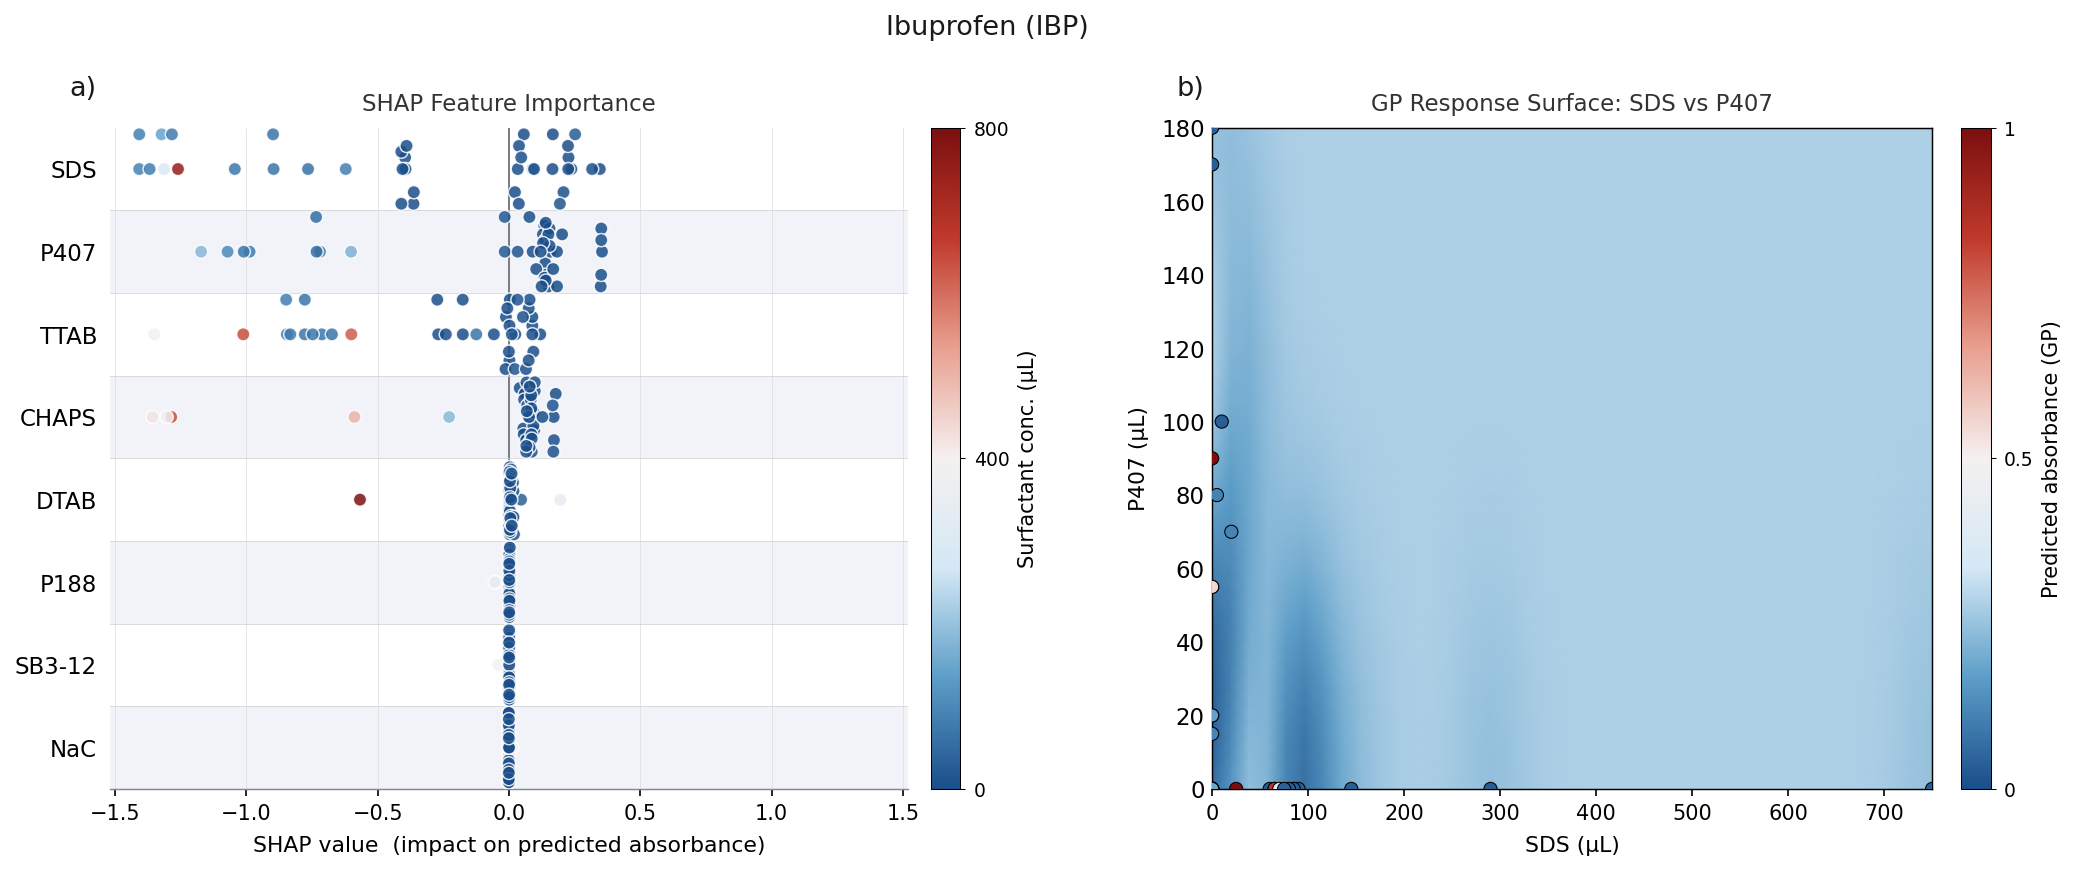

  saved → figures/model_analysis_IBP.png
[LOV] Fitting GP...


[WARNING 03-02 16:47:11] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


[LOV] Computing SHAP (39 × 8)...
[LOV] Predicting surface (TTAB × SDS)...


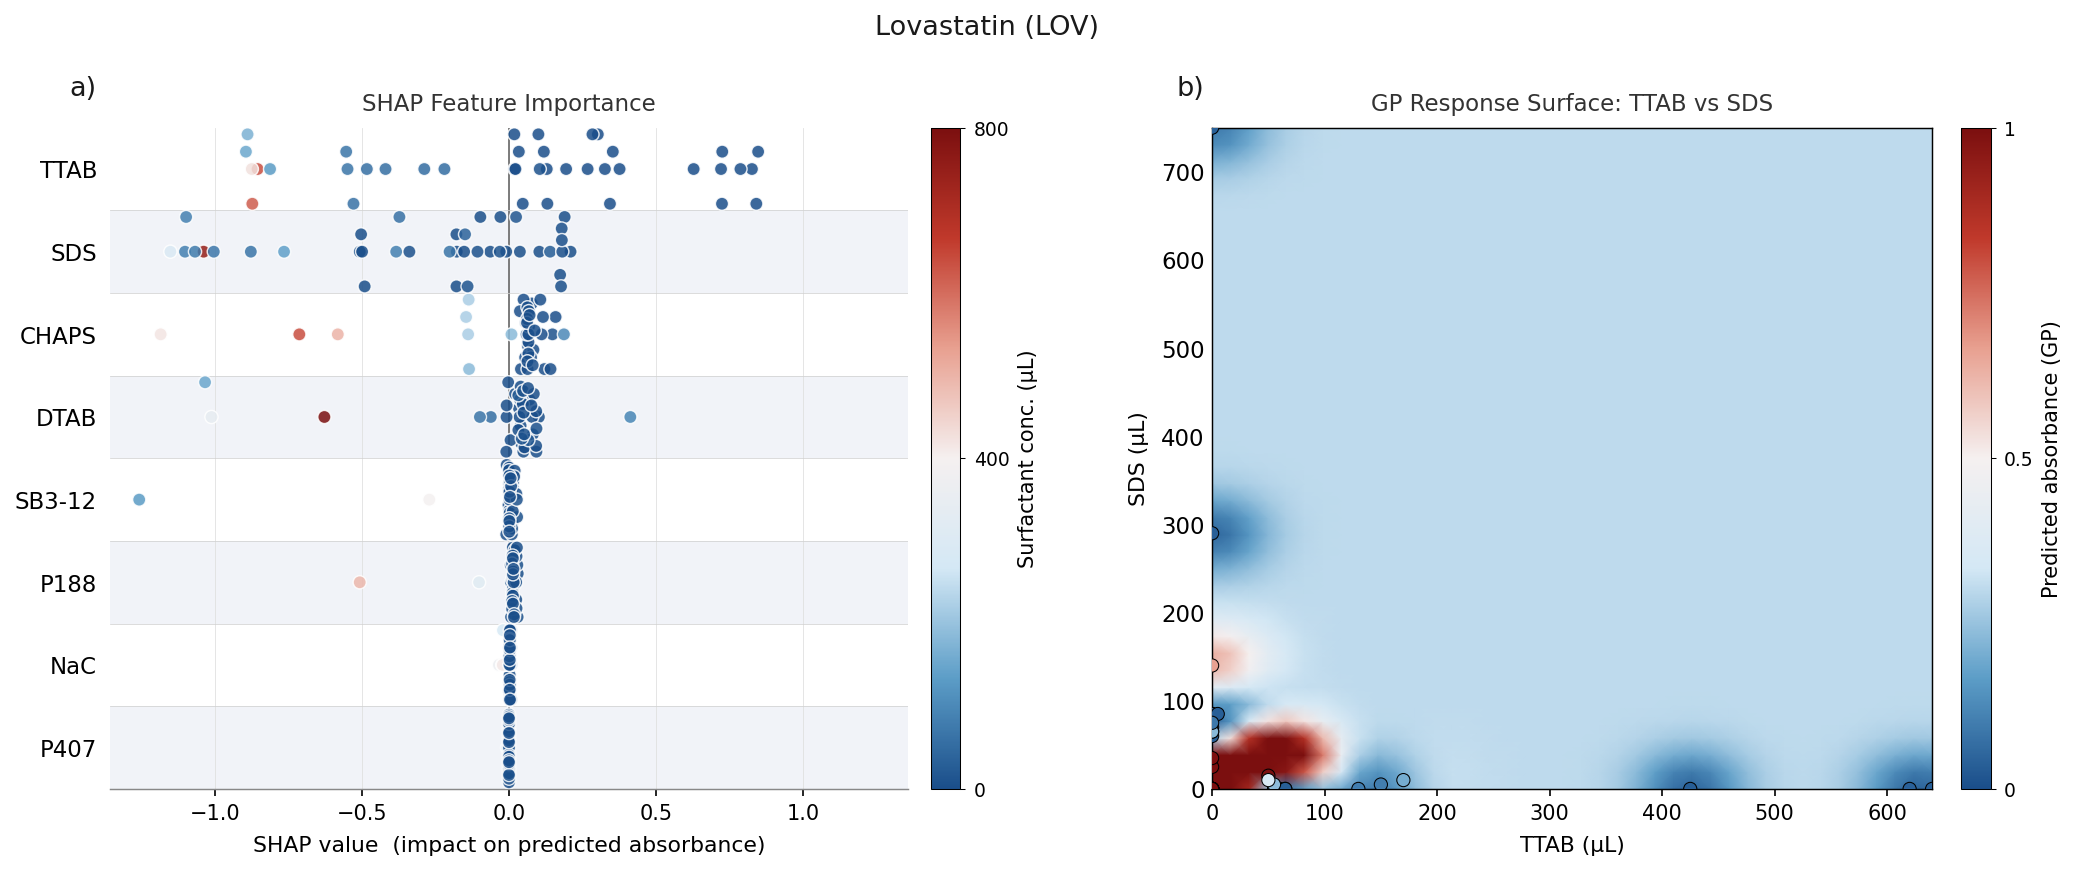

  saved → figures/model_analysis_LOV.png
[DCF] Fitting GP...


[WARNING 03-02 16:47:22] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


[DCF] Computing SHAP (39 × 8)...
[DCF] Predicting surface (SDS × TTAB)...


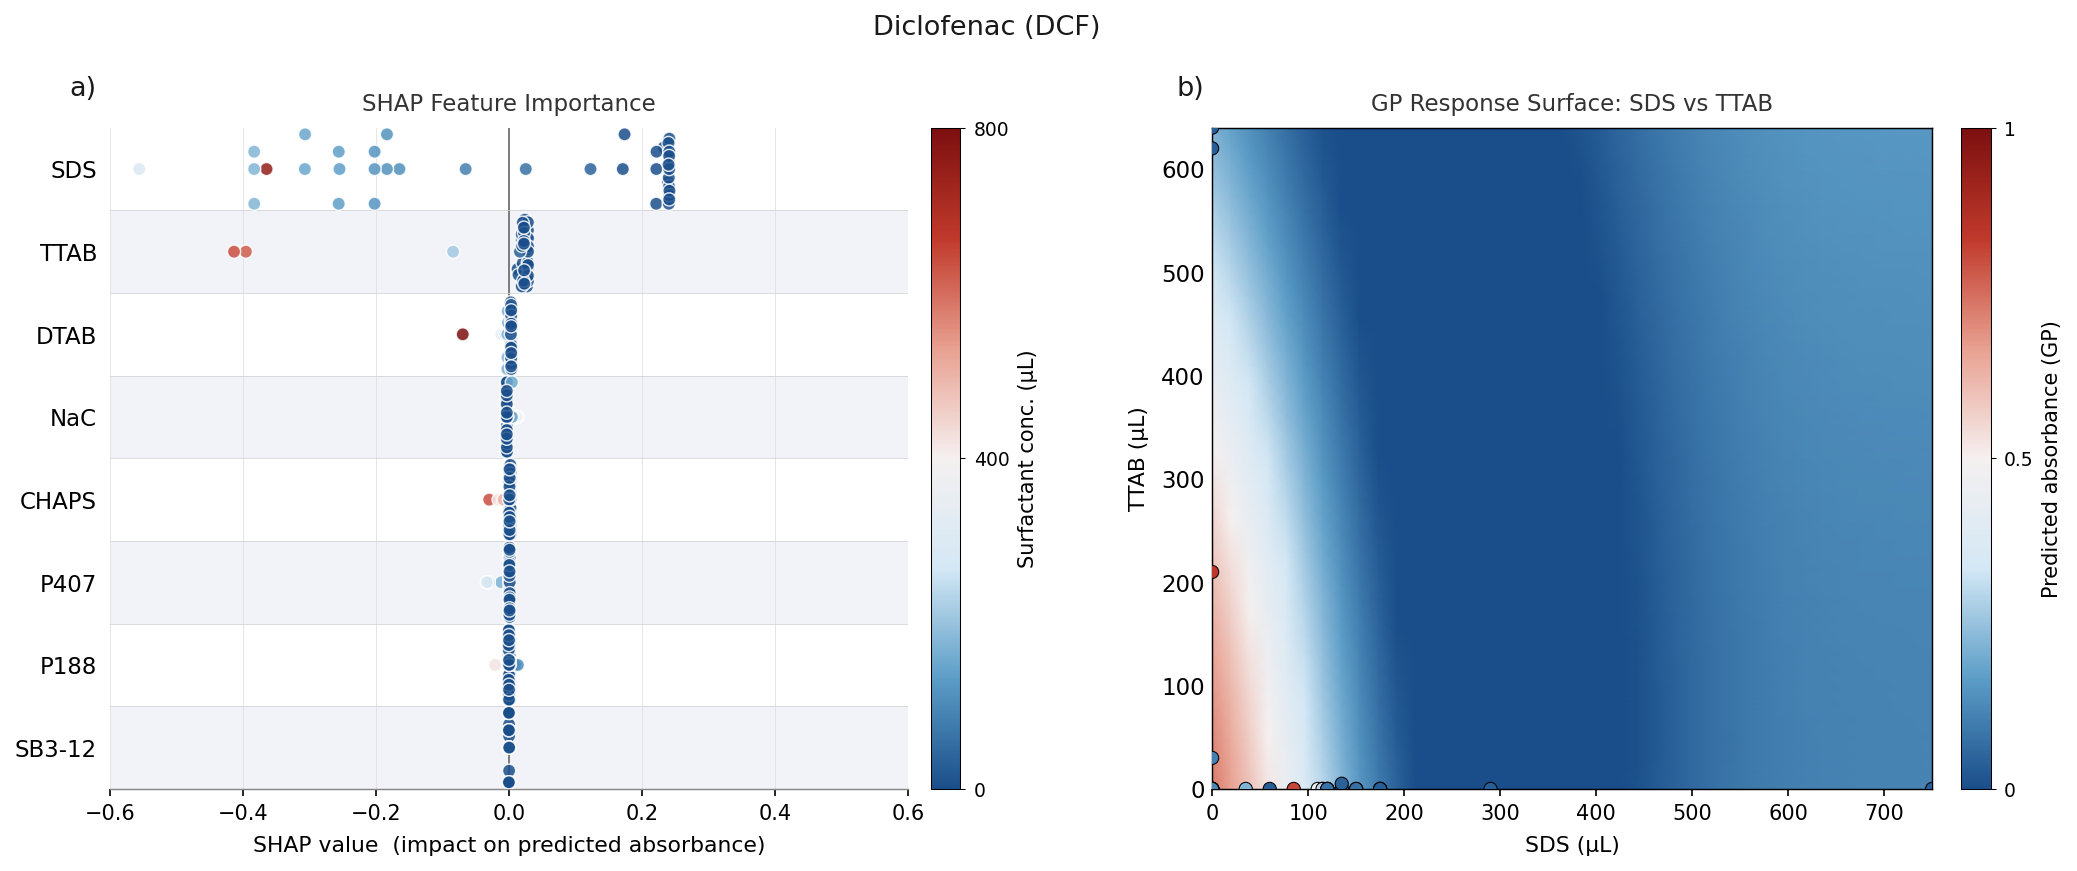

  saved → figures/model_analysis_DCF.png
[GLV] Fitting GP...


[WARNING 03-02 16:47:33] ax.service.utils.report_utils: Column reason missing for all trials. Not appending column.


[GLV] Computing SHAP (39 × 8)...
[GLV] Predicting surface (SB3-12 × P407)...


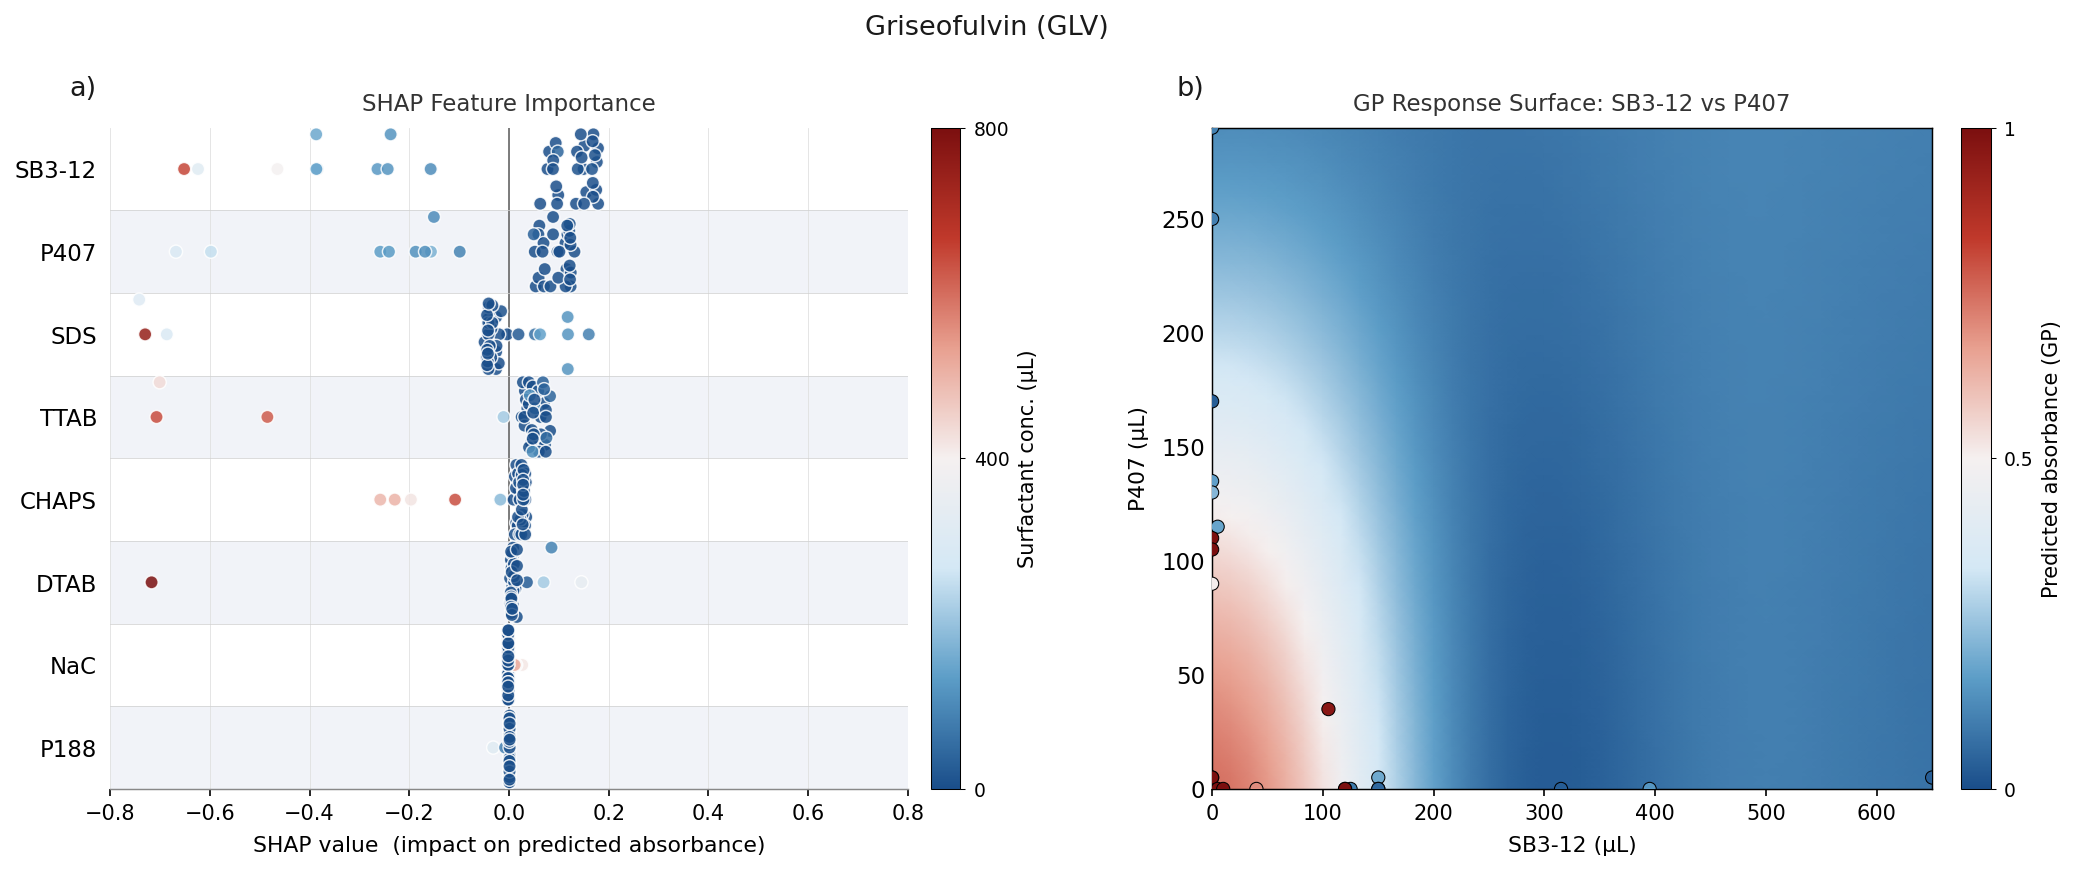

  saved → figures/model_analysis_GLV.png


In [10]:
for drug in exp_dict.keys():
    plot_drug(drug)